# [3주차] Transformer 과제

- **과제 목적:** 이번 과제는 하나의 흐름 안에서 Transformer의 핵심 연산을 직접 구현하고, 마스킹 전후를 비교한 뒤, BERT와 GPT의 예측 방식을 관찰하는 과제로 출제해봤습니다. 완성된 코드를 실행하는 것에서 끝내지 않고, 실제로 실행하며 얻은 수치와 출력 결과를 근거로 각 개념을 해석하면서 트랜스포머를 이해해주시면 됩니다!

## 전체 흐름

> Scaled Dot-Product Attention 구현 → Causal Mask 적용 → BERT와 GPT 결과 비교 → 전체 해석

### 제출 시 유의사항
- 코드 셀의 `TODO`와 주석의 빈칸을 모두 채워주세요.
- 서술형 답변은 **본인이 실행해 얻은 값이나 출력**을 반드시 이용해서 작성해주세요.
- 마지막 셀의 생성형 AI 활용 내역을 반드시 작성해주세요.


## 0. 환경 설정

아래 셀을 실행하여 필요한 라이브러리를 설치하고 시드를 고정합니다.

In [ ]:
!pip -q install transformers

import os
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# Hugging Face의 다운로드 진행바/경고를 줄여 과제 출력이 너무 길어지지 않게 합니다.
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

from transformers import (
    AutoTokenizer,
    AutoModelForMaskedLM,
    AutoModelForCausalLM,
)
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)


device: cpu


# 1. 필수 과제

## 1-1. Scaled Dot-Product Attention 직접 구현

다음 식을 코드로 구현합니다.

$$
\mathrm{Attention}(Q,K,V)
=\mathrm{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

아래 예제에서 각 행은 하나의 토큰을 나타냅니다. 코드의 빈칸과 주석을 채운 뒤, **Attention Score → Weight → Output**의 흐름을 확인해주세요.


In [ ]:
# 세 토큰의 Q, K, V 예시
Q = torch.tensor([
    [1.0, 0.0],
    [0.0, 1.0],
    [1.0, 1.0],
])

# 첫 번째 Query에서 최대 Attention이 하나만 나오도록 세 번째 Key를 [0.5, 0.5]로 둡니다.
K = torch.tensor([
    [1.0, 0.0],
    [0.0, 1.0],
    [0.5, 0.5],
])

V = torch.tensor([
    [10.0, 0.0],
    [0.0, 10.0],
    [5.0, 5.0],
])


def scaled_dot_product_attention(Q, K, V, mask=None):
    # [빈칸] d_k는 어떤 벡터의 차원을 뜻하는가?
    # 답: Query(및 Key) 벡터의 차원 수(임베딩 차원). Q와 K는 내적을 위해 같은 차원을 가져야 하므로 d_k = Q.size(-1)
    d_k = Q.size(-1)

    # TODO 1: Query와 모든 Key의 내적 계산
    scores = Q @ K.T

    # TODO 2: 내적값을 sqrt(d_k)로 나누기
    scaled_scores = scores / math.sqrt(d_k)

    # Mask가 주어진 경우 미래 위치의 score를 -inf로 바꿉니다.
    if mask is not None:
        scaled_scores = scaled_scores.masked_fill(mask, float('-inf'))

    # TODO 3: 마지막 차원에 Softmax를 적용해 Attention Weight 구하기
    weights = torch.softmax(scaled_scores, dim=-1)

    # TODO 4: Attention Weight와 Value의 가중합 계산
    output = weights @ V

    return scores, scaled_scores, weights, output

scores, scaled_scores, weights, output = scaled_dot_product_attention(Q, K, V)

print("[Raw Attention Scores]\n", scores)
print("\n[Scaled Scores]\n", scaled_scores)
print("\n[Attention Weights]\n", weights)
print("\n[Attention Output]\n", output)


[Raw Attention Scores]
 tensor([[1.0000, 0.0000, 0.5000],
        [0.0000, 1.0000, 0.5000],
        [1.0000, 1.0000, 1.0000]])

[Scaled Scores]
 tensor([[0.7071, 0.0000, 0.3536],
        [0.0000, 0.7071, 0.3536],
        [0.7071, 0.7071, 0.7071]])

[Attention Weights]
 tensor([[0.4555, 0.2246, 0.3199],
        [0.2246, 0.4555, 0.3199],
        [0.3333, 0.3333, 0.3333]])

[Attention Output]
 tensor([[6.1546, 3.8454],
        [3.8454, 6.1546],
        [5.0000, 5.0000]])


In [ ]:
# 과정 확인 장치: 각 Query의 Attention Weight 합은 1이어야 합니다.
row_sums = weights.sum(dim=-1)
print("각 행의 합:", row_sums)

# TODO 5: row_sums가 모두 1에 가까운지 검증
assert torch.allclose(row_sums, torch.ones_like(row_sums), atol=1e-6)

# 첫 번째 Query가 가장 크게 참고한 Key의 인덱스
most_attended_key = weights[0].argmax().item()
print("첫 번째 Query가 가장 크게 참고한 Key index:", most_attended_key)


각 행의 합: tensor([1., 1., 1.])
첫 번째 Query가 가장 크게 참고한 Key index: 0


### 1-1 결과 해석

1. 첫 번째 Query가 가장 크게 참고한 Key의 인덱스와 가중치는 얼마인가요?
   - **답:** index0, 가중치는 약 0.4555
2. 그 Key의 가중치가 가장 큰 이유를 Q와 K의 내적 관점에서 설명해주세요.
   - **답:** Q0=[1,0]과 K0=[1,0]의 내적이 1.0으로 세 Key 중 가장 크기 때문. K1=[0,1]과는 내적이 0, K2=[0.5,0.5]와는 0.5로 더 작다. 내적이 클수록 두 벡터의 방향(유사도)이 가깝다는 의미이고, Softmax는 큰 score에 지수적으로 더 큰 확률을 부여하므로 K0의 가중치가 가장 커진다.
3. Attention Output은 Value 하나를 그대로 선택한 결과인가요, 여러 Value를 결합한 결과인가요?
   - **답:** 여러 Value를 결합한 결과. output[0]=[6.15, 3.85]는 V0=[10,0], V1=[0,10], V2=[5,5] 중 어느 것과도 일치하지 않고 세 Value를 각각의 weight로 가중합한 값이다.
4. `sqrt(d_k)`로 나누는 Scaling이 필요한 이유를 Softmax와 연결해 설명해주세요.
   - **답:** Q·K의 차원이 커지면 내적값의 분산이 커져 score가 매우 크거나 작은 값으로 벌어지고, 이 상태로 Softmax를 통과하면 한쪽 값에 극단적으로 쏠려 확률분포가 거의 one-hot에 가까워지면서 그래디언트가 매우 작아지는 문제가 생긴다. sqrt(d_k)로 나눠 값의 스케일을 안정시켜 Softmax가 완만한 분포를 유지하고 학습이 안정적으로 되도록 한다.


## 1-2. Look-ahead Mask 적용하기

같은 Q, K, V에 **Causal Mask(Look-ahead Mask)** 를 적용해 미래 토큰을 보지 못하게 합니다. 마스크 자체와 Masked Self-Attention은 같은 말이 아닙니다.

- **Look-ahead Mask:** 미래 위치를 가리는 마스크
- **Masked Self-Attention:** Self-Attention에 Look-ahead Mask를 적용한 연산

In [ ]:
seq_len = Q.size(0)

# TODO 1: 주대각선 위쪽을 True로 갖는 마스크 만들기
# 힌트: torch.triu(..., diagonal=1)
causal_mask = torch.triu(torch.ones(seq_len, seq_len, dtype=torch.bool), diagonal=1)

_, _, unmasked_weights, _ = scaled_dot_product_attention(Q, K, V)
_, _, masked_weights, masked_output = scaled_dot_product_attention(
    Q, K, V, mask=causal_mask
)

print("[Causal Mask]\n", causal_mask)
print("\n[Mask 적용 전 Weight]\n", unmasked_weights)
print("\n[Mask 적용 후 Weight]\n", masked_weights)
print("\n[Masked Attention Output]\n", masked_output)


[Causal Mask]
 tensor([[False,  True,  True],
        [False, False,  True],
        [False, False, False]])

[Mask 적용 전 Weight]
 tensor([[0.4555, 0.2246, 0.3199],
        [0.2246, 0.4555, 0.3199],
        [0.3333, 0.3333, 0.3333]])

[Mask 적용 후 Weight]
 tensor([[1.0000, 0.0000, 0.0000],
        [0.3302, 0.6698, 0.0000],
        [0.3333, 0.3333, 0.3333]])

[Masked Attention Output]
 tensor([[10.0000,  0.0000],
        [ 3.3024,  6.6976],
        [ 5.0000,  5.0000]])


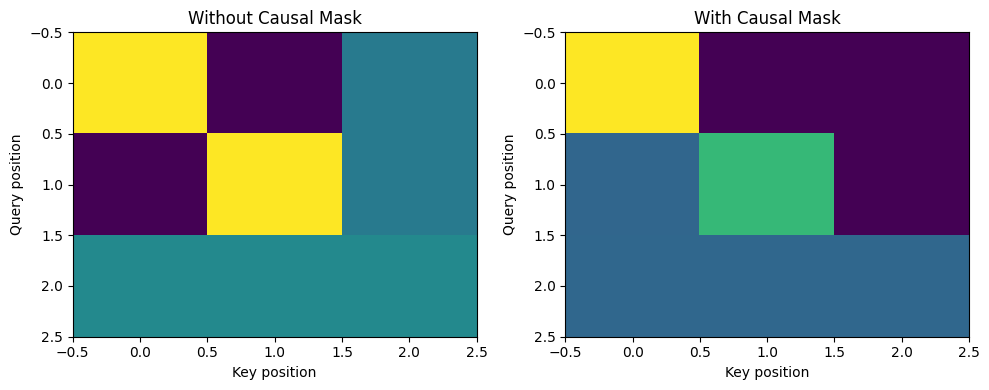

In [ ]:
# Attention Weight 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(unmasked_weights.detach().numpy(), aspect="auto")
axes[0].set_title("Without Causal Mask")
axes[0].set_xlabel("Key position")
axes[0].set_ylabel("Query position")

axes[1].imshow(masked_weights.detach().numpy(), aspect="auto")
axes[1].set_title("With Causal Mask")
axes[1].set_xlabel("Key position")
axes[1].set_ylabel("Query position")

plt.tight_layout()
plt.show()

### 1-2 결과 해석

1. Query index 0은 마스크 적용 후 어느 Key까지 참고할 수 있나요?
   - **답:** Key index0, 즉 자기 자신까지만 참고 가능
2. 마스크 적용 후 Weight 행렬이 삼각형 모양이 되는 이유를 설명해주세요.
   - **답:** 각 Query 위치 t는 자신과 그 이전 위치의 Key만 참고 가능하고, t보다 뒤에 있는 Key는 모두 -∞로 마스킹되어 weight가 0이 된다. 그 결과 0이 아닌 값들이 대각선을 포함한 아래쪽에만 남아 삼각형 모양이 된다.
3. Look-ahead Mask를 적용한 위치의 Weight가 0이 되는 과정을 `-∞ → Softmax`와 연결해 서술해주세요.
   - **답:** masked_fill로 미래 위치의 score를 -∞로 바꾸면, Softmax의 exp(-∞) = 0이 되어 정규화 후 해당 위치의 weight가 0이 된다. 즉 -∞는 확률 0으로 만들기 위한 장치이다.
4. Padding Mask와 Look-ahead Mask의 목적의 차이를 한 문장씩 간단하게 작성해주세요.
   - **Padding Mask:** 문장 길이를 맞추기 위해 넣은, 실제 의미가 없는 PAD 토큰을 Attention 계산에서 제외하기 위한 마스크
   - **Look-ahead Mask:** Decoder가 아직 생성되지 않은 미래 시점의 토큰을 미리 참고하지 못하도록 차단하는 마스크


## 1-3. BERT와 GPT의 예측 방식 비교

이제 사전학습 모델을 사용해 두 모델의 차이를 관찰합니다.

- **BERT:** Encoder 기반, 양방향 문맥, Masked Language Model
- **GPT:** Decoder 기반, Causal Mask, 이전 토큰만 이용하는 Autoregressive Language Model

두 모델은 목적이 다르므로 정확도 경쟁이 아니라, **입력과 예측 방식의 차이**를 해석하는 것이 핵심입니다.

In [ ]:
# 모델 불러오기
bert_name = "bert-base-uncased"
gpt_name = "gpt2"

# TODO 1: BERT tokenizer와 Masked LM model 불러오기
bert_tokenizer = AutoTokenizer.from_pretrained(bert_name)
bert_model = AutoModelForMaskedLM.from_pretrained(bert_name).to(DEVICE)
_ = bert_model.eval()

# TODO 2: GPT tokenizer와 Causal LM model 불러오기
gpt_tokenizer = AutoTokenizer.from_pretrained(gpt_name)
gpt_model = AutoModelForCausalLM.from_pretrained(gpt_name).to(DEVICE)
_ = gpt_model.eval()

print("BERT / GPT 모델 로드 완료")


BERT / GPT 모델 로드 완료


In [ ]:
# ----- BERT: [MASK]의 앞뒤 문맥을 모두 이용한 단어 예측 -----
# [MASK] 뒤의 "to withdraw money"까지 활용할 수 있다는 점이 핵심
bert_sentence = "I went to the [MASK] to withdraw money."
bert_inputs = bert_tokenizer(bert_sentence, return_tensors="pt").to(DEVICE)

with torch.no_grad():
    bert_logits = bert_model(**bert_inputs).logits

mask_positions = (bert_inputs["input_ids"] == bert_tokenizer.mask_token_id).nonzero(as_tuple=False)
assert len(mask_positions) == 1, "[MASK] 토큰은 정확히 하나만 있어야 합니다."
mask_index = mask_positions[0, 1].item()
mask_logits = bert_logits[0, mask_index, :]

# TODO 3: logit이 높은 상위 5개 토큰의 id 구하기
bert_top_ids = torch.topk(mask_logits, k=5).indices
bert_top_tokens = [bert_tokenizer.decode([idx]).strip() for idx in bert_top_ids]
print("문장:", bert_sentence)
print("BERT top-5 predictions:", bert_top_tokens)


문장: I went to the [MASK] to withdraw money.
BERT top-5 predictions: ['bank', 'banks', 'store', 'atm', 'office']


In [ ]:
# ----- GPT: 지금까지의 토큰만 이용한 다음 토큰 예측 -----
# GPT는 뒤 문맥을 볼 수 없으므로, 현재까지 주어진 prefix에서 다음 토큰을 예측
gpt_prompt = "I went to the bank to withdraw"
gpt_inputs = gpt_tokenizer(gpt_prompt, return_tensors="pt").to(DEVICE)

with torch.no_grad():
    gpt_logits = gpt_model(**gpt_inputs).logits

next_token_logits = gpt_logits[0, -1, :]

# TODO 4: 다음 토큰 후보 상위 5개의 id 구하기
gpt_top_ids = torch.topk(next_token_logits, k=5).indices
gpt_top_tokens = [gpt_tokenizer.decode([idx]) for idx in gpt_top_ids]
print("Prompt:", gpt_prompt)
print("GPT next-token top-5:", gpt_top_tokens)


Prompt: I went to the bank to withdraw
GPT next-token top-5: [' money', ' my', ' the', ' $', ' some']


In [ ]:
# GPT의 Autoregressive 생성 과정 관찰
prompt = "In natural language processing, Transformer models can"
inputs = gpt_tokenizer(prompt, return_tensors="pt").to(DEVICE)

# TODO 5: max_new_tokens=20, do_sample=False 조건으로 문장 생성
generated_ids = gpt_model.generate(
    **inputs,
    max_new_tokens=20,
    do_sample=False,
    pad_token_id=gpt_tokenizer.eos_token_id,
)

print(gpt_tokenizer.decode(generated_ids[0], skip_special_tokens=True))


In natural language processing, Transformer models can be used to create a model that is more accurate than the original model.

Transformer models


### 1-3 결과 해석

> **주의:** BERT/GPT의 상위 토큰과 생성 문장은 라이브러리·모델 버전에 따라 조금 달라질 수 있습니다. 반드시 **본인의 실제 출력값을 사용해** 답변을 작성해주시면 됩니다!

1. BERT의 `[MASK]` 상위 5개 예측 중 문맥상 가장 적절하다고 판단한 토큰은 무엇인가요? 그 이유는 무엇인가요?
   - **답:** ['bank', 'banks', 'store', 'atm', 'office'] 'bank'가 가장 적절하다. 'I went to the [MASK] to withdraw money'라는 문장에서 money를 뽑는 장소로 가장 자연스러운 단어이기 때문이다. 'atm'도 의미상으로는 맞지만 관용적인 표현으로는 'bank'가 더 흔하고, [MASK] 뒤에 나오는 'to withdraw money'라는 문맥까지 반영해서 1순위로 뽑힌 걸 보면 BERT가 실제로 뒤쪽 문맥을 활용하고 있다는 걸 확인할 수 있다.
2. GPT의 다음 토큰 상위 5개 중 자연스럽다고 판단한 후보 2개를 적고, 그 이유도 설명해주세요.
   - **답:** [' money', ' my', ' the', ' $', ' some']이다. ' 'money'와 '$'가 자연스럽다고 생각한다. 'withdraw money'는 가장 기본적인 관용 표현이고, 'withdraw $500'처럼 구체적인 금액이 뒤따르는 것도 실제로 아주 흔하게 사용된다. 반대로 'my'는 뒤에 money나 savings 같은 명사가 더 붙어야 완성되는 데다, 그 명사가 붙는다 해도 이 단어 자체가 은행 맥락보다 다른 표현에서 더 자주 쓰이는 다의어라서, 상위 후보에 든 게 오히려 흥미롭다.
3. BERT와 GPT의 차이를 **Bidirectional / Causal / Masked Self-Attention** 용어를 사용해 설명해주세요.
   - **답:** BERT는 Encoder 기반이라 Bidirectional하게 동작한다. [MASK] 위치를 예측할 때 앞쪽뿐 아니라 'to withdraw money'라는 뒤쪽 토큰까지 참고할 수 있어서 'bank'를 1순위로 골랐다. GPT는 Decoder 기반이고 Causal Mask를 적용한 Masked Self-Attention을 쓴다. 각 시점은 자기 이전 토큰만 볼 수 있어서, 'I went to the bank to withdraw' 다음 토큰을 예측할 때 그 뒤에 어떤 말이 올지는 전혀 모른 채 판단해야 한다. 이 구조 차이 때문에 BERT는 빈칸 채우기에, GPT는 다음 단어 생성에 각각 맞는 구조가 된다. 실제로 자동 문항 생성시 두 구조를 활용한다.
4. GPT의 생성 결과를 **Autoregressive** 관점에서 서술해주세요.
   - **답:** 생성 결과는 'In natural language processing, Transformer models can be used to create a model that is more accurate than the original model.Transformer models'이다. GPT는 한 번에 토큰 하나씩 예측하고, 그 토큰을 다시 입력에 이어붙여서 다음 토큰을 예측하는 과정을 20번 반복한 것이다. do_sample=False라 매 시점 가장 확률이 높은 토큰만 고르는 greedy decoding을 썼는데, more accurate than the original model처럼 무난하고 평범한 문장이 나왔고, 뒷부분에 Transformer models 다시 등장한 것도 greedy decoding이 반복에 취약하다는 것을 보여준다.
  


# 2. 심화 과제 (선택)

아래 **A/B 중 하나를 선택**하여 수행하세요. 선택한 실험에서는 코드 실행 결과뿐 아니라 **본인이 관찰한 출력값이나 문장 일부를 근거로 해석**해야 합니다.

---

## A안. BERT의 서로 다른 Attention Head 비교

같은 문장을 넣고 BERT의 동일 Layer 안에서 서로 다른 Head가 **특정 Query 토큰(`it`)에서 어떤 Key 토큰을 참고하는지** 비교합니다.

- 비교 문장: `The animal did not cross the street because it was tired.`
- 비교 Layer: 중간층인 Encoder Layer 8 (0-based index 7)
- 비교 Head: Head 0, Head 1
- 비교 Query: `it`
- 확인할 점: 두 Head가 `it`에서 어떤 토큰에 서로 다른 Attention을 주는지

> 마지막 Layer의 전체 Attention heatmap은 `[SEP]` 같은 특수 토큰에 Attention이 몰려 Head 차이가 잘 안 보일 수 있습니다. 따라서 **중간 Layer + 특정 Query 행**을 비교합니다.


In [ ]:
# A안: BERT Multi-Head Attention 비교
from transformers import AutoModel

# attention weight를 반환하도록 eager 구현을 사용합니다.
bert_attn_model = AutoModel.from_pretrained(
    bert_name,
    attn_implementation="eager",
).to(DEVICE)
_ = bert_attn_model.eval()

attn_sentence = "The animal did not cross the street because it was tired."
attn_inputs = bert_tokenizer(attn_sentence, return_tensors="pt").to(DEVICE)

with torch.no_grad():
    attn_outputs = bert_attn_model(**attn_inputs, output_attentions=True)

# attentions: tuple(num_layers), 각 원소 shape = [batch, num_heads, seq_len, seq_len]
attentions = attn_outputs.attentions
assert attentions is not None, "Attention이 반환되지 않았습니다. attn_implementation='eager' 설정을 확인하세요."

tokens = bert_tokenizer.convert_ids_to_tokens(attn_inputs["input_ids"][0])

# TODO 1: 8번째 Encoder layer(0-based index 7)를 선택
layer_idx = ____
layer_attn = attentions[layer_idx][0].detach().cpu()

# TODO 2: Query 토큰 'it'의 위치 찾기.
it_idx = ______________________________

# TODO 3: Head 0과 Head 1에서 Query='it'이 모든 Key 토큰에 주는 Attention 가져오기
head0_it = ______________________________
head1_it = ______________________________

print("tokens:", tokens)
print("layer attention shape:", layer_attn.shape)
print("query token:", tokens[it_idx], "(index", it_idx, ")")

# 특수 토큰까지 포함한 전체 분포를 막대그래프로 비교
x = np.arange(len(tokens))
width = 0.38
plt.figure(figsize=(14, 5))
plt.bar(x - width/2, head0_it.numpy(), width, label="Head 0")
plt.bar(x + width/2, head1_it.numpy(), width, label="Head 1")
plt.xticks(x, tokens, rotation=60)
plt.ylabel("Attention weight from query 'it'")
plt.title(f"Layer {layer_idx+1}: Attention from 'it' to each token")
plt.legend()
plt.tight_layout()
plt.show()

# 각 Head에서 'it'이 가장 많이 참고한 일반 토큰 확인
# [CLS], [SEP]는 해석을 위해 제외합니다.
special_ids = {0, len(tokens)-1}
valid_indices = [i for i in range(len(tokens)) if i not in special_ids]

def top_key_for_head(weights, valid_indices):
    best = max(valid_indices, key=lambda i: float(weights[i]))
    return best, tokens[best], float(weights[best])

for h, w in [(0, head0_it), (1, head1_it)]:
    idx, tok, val = top_key_for_head(w, valid_indices)
    print(f"Head {h}: 'it'이 가장 크게 참고한 일반 토큰 = {tok!r} (index={idx}, weight={val:.4f})")

mean_abs_diff = torch.mean(torch.abs(head0_it - head1_it)).item()
print(f"Head 0과 Head 1의 'it' attention 분포 평균 절대 차이: {mean_abs_diff:.6f}")


KeyboardInterrupt: 

### A안 결과 해석

- **선택:** A
- **변경한 조건:**
- **관찰 결과:** Head 0과 Head 1에서 `it`이 가장 크게 참고한 토큰과 가중치를 각각 실제 출력값을 이용해서 설명해주세요.
- **해석:** 두 Head의 Attention 분포가 왜 다를 수 있는지 Multi-Head Attention의 Q/K/V projection과 연결하여 설명하세요.

---

## B안. GPT Temperature에 따른 생성 다양성 비교

같은 Prompt에서 **temperature만 변경**했을 때 생성 결과의 다양성과 자연스러움이 어떻게 달라지는지 비교합니다.

- Prompt는 모든 실험에서 동일하게 유지합니다.
- `temperature = 0.3, 0.8, 1.5`를 비교합니다.
- 각 temperature에서 **3회 생성**합니다.
- `top_k=50`, 생성 길이 등 나머지 조건은 동일하게 유지합니다.
- 생성 결과의 **다양성(Diversity)** 과 **문맥의 자연스러움(Coherence)** 을 비교합니다.

### 확인할 질문
1. 어느 temperature에서 3개의 생성 결과가 가장 비슷했고, 어느 temperature에서 가장 다양했나요? 실제 생성 문장의 일부를 근거로 설명해세요.
2. temperature가 높아질수록 문장의 자연스러움과 다양성이 어떻게 변했나요? 예상과 다른 결과가 나왔다면 그 결과도 그대로 편하게 적어주세요.
3. temperature가 Softmax 확률분포에 미치는 영향을 위 실험 결과와 연결해 설명하세요.


In [ ]:
# B안: temperature에 따른 GPT 생성 다양성 비교
# 여러 방향으로 자연스럽게 이어질 수 있는 prompt를 사용합니다.
prompt = "Once upon a time, a robot discovered"

# TODO 1: 비교할 temperature 값을 입력
temps = [0.3, 0.8, 1.5]

# top_k, 생성 길이 등은 모든 조건에서 동일하게 고정하고
# temperature만 변경하여 그 효과를 비교합니다.
for temp in temps:
    print(f"\n===== temperature={temp} =====")

    # 같은 temperature에서도 3번 생성하여 결과의 다양성을 확인합니다.
    for trial in range(3):
        # 각 temperature에서 같은 trial끼리는 동일한 seed를 사용합니다.
        torch.manual_seed(SEED + trial)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(SEED + trial)

        temp_inputs = gpt_tokenizer(
            prompt,
            return_tensors="pt"
        ).to(DEVICE)

        generated = gpt_model.generate(
            **temp_inputs,
            # TODO 2: 새롭게 생성할 토큰 수를 40으로 설정
            max_new_tokens=40,
            # TODO 3: sampling을 사용하도록 설정
            do_sample=True,
            # TODO 4: 현재 반복문의 temperature를 적용
            temperature=temp,
            # 모든 조건에서 동일하게 유지합니다.
            top_k=50,
            pad_token_id=gpt_tokenizer.eos_token_id,
        )

        text = gpt_tokenizer.decode(
            generated[0],
            skip_special_tokens=True
        )

        print(f"\n[생성 {trial + 1}]")
        print(text)



===== temperature=0.3 =====

[생성 1]
Once upon a time, a robot discovered that it could not be used to pick up the pieces of the puzzle. The robot then began to search for the pieces.

The robot then began to search for the pieces of the puzzle.

[생성 2]
Once upon a time, a robot discovered that it was a human. The robot then began to take over the world, and the humans were able to stop it.

The robot was eventually destroyed by a group of robots. The robot

[생성 3]
Once upon a time, a robot discovered that the world was in danger. It was a robot that had been programmed to be able to survive in a vacuum. The robot was able to survive in a vacuum for a long time and was able

===== temperature=0.8 =====

[생성 1]
Once upon a time, a robot discovered that there was a way to stop the world from ending, and it had a method to do so. The robot's design was so strong that it could drive its own wheels, and it had a

[생성 2]
Once upon a time, a robot discovered that he was on his way to get his 

### 확인할 질문
1. 어느 temperature에서 3개의 생성 결과가 가장 비슷했고, 어느 temperature에서 가장 다양했나요? 실제 생성 문장의 일부를 근거로 설명해세요.
>> temp=0.3에서 세 결과가 제일 비슷했다. 셋 다 로봇이 위기 상황에 대처하거나 뭔가를 찾아 나서는 전개로 흘러가고, 'The robot then began to search for the pieces'라는 문장이 첫 번째 생성 안에서 그대로 두 번 반복될 만큼 구조 자체가 겹친다. temp=1.5에서는 완전히 다르다. 첫 번째는 실이 로봇을 묶고 있다는 초현실적인 전개이고 두 번째는 문(door)에 관한 뜬금없고, 세 번째는 AI 기술의 결함이라는 완전히 다른 세 방향으로 나눠졌고 문장 구조도 서로 다르다.

2. temperature가 높아질수록 문장의 자연스러움과 다양성이 어떻게 변했나요? 예상과 다른 결과가 나왔다면 그 결과도 그대로 편하게 적어주세요.
>> 다양성은 예상대로 temp가 올라갈수록 커졌다. 반면 자연스러움은 temp=0.3과 0.8까지는 문법과 의미가 크게 무너지지 않았는데, temp=1.5에서는 'reclanging the wires'처럼 실제로 존재하지 않는 단어가 튀어나오고 따옴표 처리도 꼬이는 지점이 보였다. 예상과 좀 달랐던 건 temp=0.8이 여전히 상당히 멀쩡한 문장을 유지했다는 점이다. 로봇이 머리를 자르러 간다는 다소 엉뚱한 전개('he was on his way to get his hair cut')가 나오긴 했지만 문법 자체는 오류가 없었는데, top_k=50으로 후보를 미리 제한해둔 게 temp를 어느 정도 올려도 어느 정도 방지해준 것 같다.그동안 연구를 진행하며 temp=0으로 고정할 때 근원적 이유까지는 알아보지 않았는데 이러한 이유 때문인 것을 이번에 실습하며 알았다.

3. temperature가 Softmax 확률분포에 미치는 영향을 위 실험 결과와 연결해 설명하세요.
>> temperature는 softmax에 들어가기 전 logit을 나눠주는 역할을 한다. temp가 작으면(0.3) logit 차이가 상대적으로 크게 벌어져서 확률이 한두 개의 토큰에 뾰족하게 몰리고, 그래서 매번 비슷한 토큰이 뽑혀 세 생성 결과가 서로 닮게 나온다. temp가 크면(1.5) logit 차이가 완만해져 확률분포가 넓게 퍼지고, 원래 확률이 낮았던 토큰도 뽑힐 기회가 커지면서 다양성은 늘어나지만 문법이나 의미가 이상한 토큰까지 섞여 나올 위험도 같이 커진다. 실제로 temp=1.5에서만 'reclanging' 같은 부자연스러운 단어가 나온 게 이 확률 분산 효과를 그대로 보여준다.

### B안 결과 해석

- **선택:** B
- **변경한 조건:** 어떤 조건을 고정하고 무엇만 변경했는지 작성하세요.
- **관찰 결과:** temperature별 3개의 실제 생성 결과를 비교하고, 구체적인 문장 일부를 인용하세요.
- **해석:** `temperature → Softmax 확률분포 → 다양성/자연스러움`의 관계를 설명하세요.
- **주의:** Sampling 결과는 확률적이므로 이론적인 경향과 완벽하게 일치하지 않을 수 있습니다. 예상과 다른 결과가 나오더라도 실제 출력값을 근거로 타당하게 해석하세요.


# 3. 전체 결과 정리 및 회고

아래 표를 **본인의 실제 실행 결과**를 바탕으로 채워주세요.

| 단계 | 본인이 관찰한 핵심 결과 | 연결되는 개념 |
|---|---|---|
| Attention 직접 구현 | Query 0가 Key 0에 가장 큰 weight(0.4555). Query 2처럼 세 Key와 내적이 모두 같으면 weight가 정확히 1/3씩 나뉨 |Softmax 정규화 |
| Causal Mask 적용 |mask 적용 후 weight 행렬이 삼각형. 미래 weight만 0  | Masked Self-Attention, -∞ → Softmax → 0 |
| BERT 실험 | [MASK] 예측에서 'bank'가 1순위 |Bidirectional Attention, Masked Language Model |
| GPT 실험 |다음 토큰 예측에서 ' money'가 1순위, greedy 생성에서는 Transformer models 뒤에서 그대로 반복  | Causal Mask, Autoregressive 생성 |

1. **가장 어려웠던 단계와 해결 방법**
   - 답: 심화과제 A도 도전해보고 싶었는데, AutoModel import에서 layer_idx, it_idx 같은 빈칸을 채워도 실행이 끝까지 안 됐던 부분이다.
2. **실행 전 예상과 실제 결과가 가장 달랐던 부분**
   - 답:  GPT 다음 토큰 예측에서 ' my'가 상위 5개 안에 든 게 예상 밖이었다. withdraw 뒤에 오는 자연스러운 단어로는 money, $, some 정도를 예상했었따.
3. **기술블로그의 ‘과제 복습’ 섹션에 정리할 핵심 개념**
   - 답: causal mask가 -∞를 거쳐 softmax에서 0이 되는 메커니즘, BERT(Bidirectional MLM)와 GPT(Causal Autoregressive)의 구조적 차이, 그리고 temperature가 softmax 확률분포의 뾰족함을 조절해서 생성 다양성에 영향을 준다.


# 4. 생성형 AI 활용 방법 및 대화 내역

> **반드시 작성하세요.** 문제를 풀면서 GPT, Claude 등 생성형 AI를 어디에 어떻게 사용했는지 기록합니다.

## 1) 활용한 생성형 AI
- 사용한 도구: Claude
- 사용한 문제/단계: 1-3번에 2번
- 사용 목적: `개념 확인 / 오류 해결 / 코드 초안 / 결과 해석 / 기타`
내가 생각한 답과의 비교

## 2) AI 답변을 그대로 사용하지 않고 직접 검증한 방법
- 답:

## 3) AI와의 실제 대화 내역
### 대화 내역
해당 결과에서 'my'가 top 후보에 들어갈 수 있는 이유
